In [1]:
import numpy as np
import pandas as pd
import corner
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
import h5py 
from numpy.linalg import svd
import seaborn as sns
from matplotlib import gridspec
from scipy.stats import gaussian_kde
import matplotlib.ticker as ticker 

/home/admin/anaconda3/envs/siom-igwn-py310-20241016/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
def extract_dchi (data, plist):
    #par0 = 'dchi'+ plist[0]
    dchi = np.zeros([len(data[plist[0]]),len(plist)]);
    for i in range(len(plist)):
        dchi[:,i] = data[plist[i]];
    return dchi

In [3]:
# Example of matplotlib settings using latex rendering etc
fig_width_pt  = 245.27 #513.17              # Get this from LaTeX using \showthe\columnwidth
inches_per_pt = 1.0/72.27                   # Convert pt to inches
golden_mean   = (np.sqrt(5)-1.0)/2.0        # Aesthetic ratio
fig_width     = fig_width_pt*inches_per_pt  # width in inches
fig_height    = fig_width*golden_mean       # height in inches
fig_size      = [fig_width,fig_height]

params = {
    'backend' : 'module://matplotlib_inline.backend_inline',
    'axes.labelsize': 10,
    'lines.markersize': 4,
    'font.size': 10,
    'xtick.major.size':6,
    'xtick.minor.size':3,  
    'ytick.major.size':6,
    'ytick.minor.size':3, 
    'xtick.major.width':0.5,
    'ytick.major.width':0.5,
    'xtick.minor.width':0.5,
    'ytick.minor.width':0.5,
    'lines.markeredgewidth':1,
    'axes.linewidth':1.2,
    'legend.fontsize': 7,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'savefig.dpi':200,
    'path.simplify':True,
    'font.family': 'serif',
    'font.sans-serif': ['Bitstream Vera Sans'],
    #'font.serif': ['Times New Roman'],
    'text.latex.preamble': r'\usepackage{amsmath}',
    'text.usetex':False,
    'figure.figsize': fig_size
}
plt.rcParams.update(params)

In [4]:
mpl.rcParams['text.usetex'] = False
mpl.rcParams['axes.unicode_minus'] = False

In [5]:
File_S241011k_doctS='data_files/siom_analysis_data0_1412725132-9554443_analysis_H1V1_merge_result.hdf5'
File_S241011k_doctS_half_prior='data_files/siom_half_prior_analysis_data0_1412725132-9554443_analysis_H1V1_merge_result.hdf5'
File_S241011k_doct1='data_files/siom_analysis_dL1_data0_1412725132-9554443_analysis_H1V1_merge_result.hdf5'
File_S241011k_doct1_half_prior='data_files/siom_analysis_dL1_half_prior_data0_1412725132-9554443_analysis_H1V1_merge_result.hdf5'
File_S241011k_dquad1_doct1='data_files/kappa1_lambda1_data0_1412725132-9554443_analysis_H1V1_merge_result.hdf5'
File_S241011k_dquad1_doct1_half_prior='data_files/kappa1_lambda1_half_prior_data0_1412725132-9554443_analysis_H1V1_merge_result.hdf5'
File_S241011k_dquadS_doctS='data_files/siqm_and_siom_data0_1412725132-9554443_analysis_H1V1_merge_result.hdf5'
File_S241011k_dquadS_doctS_half_prior='data_files/siqm_and_siom_half_prior_data0_1412725132-9554443_analysis_H1V1_merge_result.hdf5'
File_S241011k_injection_dquadS_doctS='data_files/siqm_and_siom_analysis_data0_1412725132-97_analysis_H1V1_merge_result.hdf5'
File_S241011k_injection_dquadS_doctS_half_prior='data_files/siqm_and_siom_analysis_half_prior_data0_1412725132-97_analysis_H1V1_merge_result.hdf5'

In [7]:
with h5py.File(File_S241011k_doctS, 'r') as f:
    File_S241011k_doctS_O = f['posterior']['dOctupoleS'][:]
    
with h5py.File(File_S241011k_doctS_half_prior, 'r') as f:
    File_S241011k_doctS_half_prior_O = f['posterior']['dOctupoleS'][:]

with h5py.File(File_S241011k_doct1,'r') as f:
    File_S241011k_siom_O= f['posterior']['dOctupole1'][:]

with h5py.File(File_S241011k_doct1_half_prior,'r') as f:
    File_S241011k_siom_O_hp= f['posterior']['dOctupole1'][:]

with h5py.File(File_S241011k_dquad1_doct1, 'r') as f:
    File_S241011k_dquad1_doct1_QI = f['posterior']['dQuadMon1'][:]
    File_S241011k_dquad1_doct1_OI = f['posterior']['dOctupole1'][:]

with h5py.File(File_S241011k_dquad1_doct1_half_prior, 'r') as f:
    File_S241011k_dquad1_doct1_QI_hp = f['posterior']['dQuadMon1'][:]
    File_S241011k_dquad1_doct1_OI_hp = f['posterior']['dOctupole1'][:]

with h5py.File(File_S241011k_dquadS_doctS, 'r') as f:
    File_S241011k_dquadS_doctS_O = f['posterior']['dOctupoleS'][:]
    File_S241011k_dquadS_doctS_Q = f['posterior']['dQuadMonS'][:]

with h5py.File(File_S241011k_dquadS_doctS_half_prior) as f:
    File_S241011k_dquadS_doctS_half_prior_O = f['posterior']['dOctupoleS'][:]
    File_S241011k_dquadS_doctS_half_prior_Q = f['posterior']['dQuadMonS'][:]

with h5py.File(File_S241011k_injection_dquadS_doctS, 'r') as f:
    File_S241011k_dquadS_doctS_O_inj = f['posterior']['dOctupoleS'][:]
    File_S241011k_dquadS_doctS_Q_inj = f['posterior']['dQuadMonS'][:]

with h5py.File(File_S241011k_injection_dquadS_doctS_half_prior, 'r') as f:
    File_S241011k_dquadS_doctS_O_inj_hp = f['posterior']['dOctupoleS'][:]
    File_S241011k_dquadS_doctS_Q_inj_hp = f['posterior']['dQuadMonS'][:]

Script to generate Figure1 of the paper.

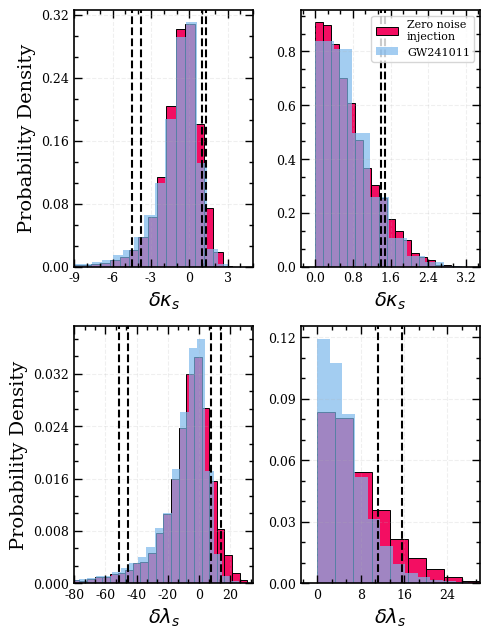

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(5, 6.5))
(ax1, ax2), (ax3, ax4) = axes  # Unpacking the 2x2 grid for easy access

# --- Common styling for all subplots ---
for ax in axes.flat:
    ax.grid(True, linestyle='--', alpha=0.2)
    # Applying tick_params to all: inward direction, boxed look
    ax.tick_params(axis='both', which='both', direction='in', 
                   top=True, right=True, labelsize=9,width=1)
    ax.set_ylabel("Probability Density", fontsize=14)

# --- Subplot 1 (Top Left) ---
ax1.hist(File_S241011k_dquadS_doctS_Q_inj, bins=30, color='#F30E62', 
         density=True, histtype='bar', linewidth=0.7,edgecolor='k')
ax1.hist(File_S241011k_dquadS_doctS_Q, bins=30, color='#7DB8EC', 
         density=True, histtype='bar', linewidth=0.7,alpha=0.7)
ax1.axvline(np.percentile(File_S241011k_dquadS_doctS_Q, 5), color='k', linestyle='--', linewidth=1.5)
ax1.axvline(np.percentile(File_S241011k_dquadS_doctS_Q, 95), color='k', linestyle='--', linewidth=1.5)
ax1.axvline(np.percentile(File_S241011k_dquadS_doctS_Q_inj, 5), color='k', linestyle='--', linewidth=1.5)
ax1.axvline(np.percentile(File_S241011k_dquadS_doctS_Q_inj, 95), color='k', linestyle='--', linewidth=1.5)
ax1.set_xlim(-9, 5)
ax1.set_xlabel(r"$\delta\kappa_s$", fontsize=14)

# Tickers for Subplot 1
ax1.xaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))  # 5 minors per major (every 10)
ax1.yaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))  # 5 minors per major (every 10)
# --- Subplot 2 (Top Right) ---
ax2.hist(File_S241011k_dquadS_doctS_Q_inj_hp, bins=18, color='#F30E62', 
         density=True, histtype='bar', linewidth=0.7, edgecolor='k',label='Zero noise\ninjection')
ax2.hist(File_S241011k_dquadS_doctS_half_prior_Q, bins=9, color='#7DB8EC', 
         density=True, histtype='bar', linewidth=0.7, alpha=0.7,label='GW241011')
ax2.axvline(np.percentile(File_S241011k_dquadS_doctS_half_prior_Q, 90), color='k', linestyle='--', linewidth=1.5)
ax2.axvline(np.percentile(File_S241011k_dquadS_doctS_Q_inj_hp, 90), color='k', linestyle='--', linewidth=1.5)
ax2.set_xlim(-0.3, 3.5)
ax2.set_xlabel(r"$\delta\kappa_s$", fontsize=14)
ax2.set_ylabel('') # Removing duplicate label for right side
ax2.legend(fontsize=8)
# Tickers for Subplot 2
ax2.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
ax2.yaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))
# --- Subplot 3 (Bottom Left) ---
ax3.hist(File_S241011k_dquadS_doctS_O_inj, bins=90, color='#F30E62', 
         density=True, histtype='bar', linewidth=0.7, edgecolor='k')
ax3.hist(File_S241011k_dquadS_doctS_O, bins=90, color='#7DB8EC', 
         density=True, histtype='bar', linewidth=0.7,alpha=0.7)
ax3.axvline(np.percentile(File_S241011k_dquadS_doctS_O, 5), color='k', linestyle='--', linewidth=1.5)
ax3.axvline(np.percentile(File_S241011k_dquadS_doctS_O, 95), color='k', linestyle='--', linewidth=1.5)
ax3.axvline(np.percentile(File_S241011k_dquadS_doctS_O_inj, 5), color='k', linestyle='--', linewidth=1.5)
ax3.axvline(np.percentile(File_S241011k_dquadS_doctS_O_inj, 95), color='k', linestyle='--', linewidth=1.5)
ax3.set_xlim(-80,35)
ax3.set_xlabel(r"$\delta\lambda_s$", fontsize=14)

# Tickers for Subplot 3
ax3.xaxis.set_major_locator(ticker.MaxNLocator(6)) # Auto-find 6 best ticks
ax3.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
ax3.yaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax3.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))

# --- Subplot 4 (Bottom Right) ---
ax4.hist(File_S241011k_dquadS_doctS_O_inj_hp, bins=11,color='#F30E62', 
         density=True, histtype='bar', linewidth=0.7, edgecolor='k')
ax4.hist(File_S241011k_dquadS_doctS_half_prior_O, bins=17, color='#7DB8EC', 
         density=True, histtype='bar', linewidth=0.7,alpha=0.7)
ax4.axvline(np.percentile(File_S241011k_dquadS_doctS_half_prior_O, 90), color='k', linestyle='--', linewidth=1.5)
ax4.axvline(np.percentile(File_S241011k_dquadS_doctS_O_inj_hp, 90), color='k', linestyle='--', linewidth=1.5)
ax4.set_xlim(-3, 30)
ax4.set_xlabel(r"$\delta\lambda_s$", fontsize=14)
ax4.set_ylabel('')

# Tickers for Subplot 4
ax4.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax4.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
ax4.yaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax4.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))

# Final adjustments
plt.tight_layout()
plt.savefig('figures/dKs_dLs_real_vs_injection_final.png', dpi=300) # Save as PDF for high-quality LaTeX/Beamer
plt.show()

Script to generate figure2 of the paper.

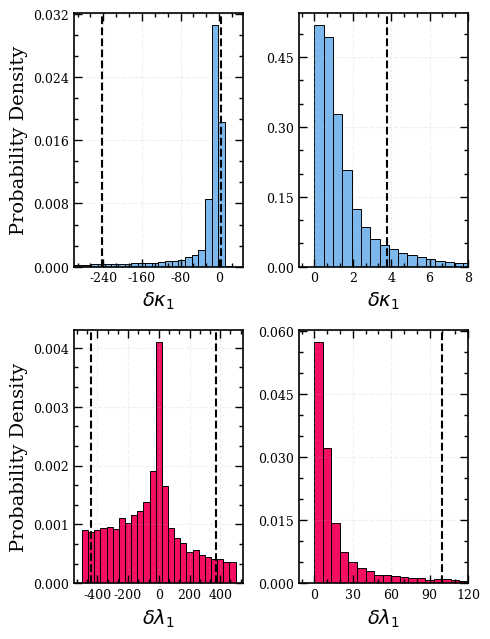

In [9]:
# Create the figure and axes objects
fig, axes = plt.subplots(2, 2, figsize=(5, 6.5))
(ax1, ax2), (ax3, ax4) = axes  # Unpacking the 2x2 grid for easy access

# --- Common styling for all subplots ---
for ax in axes.flat:
    ax.grid(True, linestyle='--', alpha=0.2)
    # Applying tick_params to all: inward direction, boxed look
    ax.tick_params(axis='both', which='both', direction='in', 
                   top=True, right=True, labelsize=9,width=1)
    ax.set_ylabel("Probability Density", fontsize=14)

# --- Subplot 1 (Top Left) ---
ax1.hist(File_S241011k_dquad1_doct1_QI, bins=40, color='#7DB8EC', 
         density=True, histtype='bar', linewidth=0.7,edgecolor='k')
ax1.axvline(np.percentile(File_S241011k_dquad1_doct1_QI, 5), color='k', linestyle='--', linewidth=1.5)
ax1.axvline(np.percentile(File_S241011k_dquad1_doct1_QI, 95), color='k', linestyle='--', linewidth=1.5)
ax1.set_xlim(-300, 50)
ax1.set_xlabel(r"$\delta\kappa_1$", fontsize=14)

# Tickers for Subplot 1
ax1.xaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))  # 5 minors per major (every 10)
ax1.yaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))  # 5 minors per major (every 10)
# --- Subplot 2 (Top Right) ---
ax2.hist(File_S241011k_dquad1_doct1_QI_hp, bins=800, color='#7DB8EC', 
         density=True, histtype='bar', linewidth=0.7, edgecolor='k')
ax2.axvline(np.percentile(File_S241011k_dquad1_doct1_QI_hp, 90), color='k', linestyle='--', linewidth=1.5)
ax2.set_xlim(-0.8, 8)
ax2.set_xlabel(r"$\delta\kappa_1$", fontsize=14)
ax2.set_ylabel('') # Removing duplicate label for right side

# Tickers for Subplot 2
ax2.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
ax2.yaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))

# --- Subplot 3 (Bottom Left) ---
ax3.hist(File_S241011k_dquad1_doct1_OI, bins=25, color='#F30E62', 
         density=True, histtype='bar', linewidth=0.7,edgecolor='k')
ax3.axvline(np.percentile(File_S241011k_dquad1_doct1_OI, 5), color='k', linestyle='--', linewidth=1.5)
ax3.axvline(np.percentile(File_S241011k_dquad1_doct1_OI, 95), color='k', linestyle='--', linewidth=1.5)
ax3.set_xlabel(r"$\delta\lambda_1$", fontsize=14)

# Tickers for Subplot 3
ax3.xaxis.set_major_locator(ticker.MaxNLocator(6)) # Auto-find 6 best ticks
ax3.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
ax3.yaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax3.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))

# --- Subplot 4 (Bottom Right) ---
ax4.hist(File_S241011k_dquad1_doct1_OI_hp, bins=60, color='#F30E62', 
         density=True, histtype='bar', linewidth=0.7,edgecolor='k')
ax4.axvline(np.percentile(File_S241011k_dquad1_doct1_OI_hp, 90), color='k', linestyle='--', linewidth=1.5)
ax4.set_xlim(-12, 120)
ax4.set_xlabel(r"$\delta\lambda_1$", fontsize=14)
ax4.set_ylabel('')

# Tickers for Subplot 4
ax4.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax4.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
ax4.yaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax4.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))

# Final adjustments
plt.tight_layout()
plt.savefig('figures/dK1_dL1_final.png', dpi=300) # Save as PDF for high-quality LaTeX/Beamer
plt.show()

Scripts to generate the figure3 of the paper.

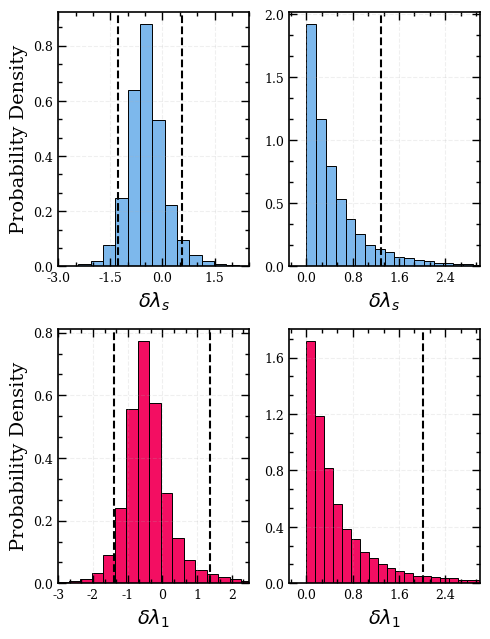

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(5, 6.5))
(ax1, ax2), (ax3, ax4) = axes  # Unpacking the 2x2 grid for easy access

# --- Common styling for all subplots ---
for ax in axes.flat:
    ax.grid(True, linestyle='--', alpha=0.2)
    # Applying tick_params to all: inward direction, boxed look
    ax.tick_params(axis='both', which='both', direction='in', 
                   top=True, right=True, labelsize=9,width=1)
    ax.set_ylabel("Probability Density", fontsize=14)

# --- Subplot 1 (Top Left) ---
ax1.hist(File_S241011k_doctS_O, bins=50, color='#7DB8EC', 
         density=True, histtype='bar', linewidth=0.7,edgecolor='k')
ax1.axvline(np.percentile(File_S241011k_doctS_O, 5), color='k', linestyle='--', linewidth=1.5)
ax1.axvline(np.percentile(File_S241011k_doctS_O, 95), color='k', linestyle='--', linewidth=1.5)
ax1.set_xlim(-3, 2.5)
ax1.set_xlabel(r"$\delta\lambda_s$", fontsize=14)

# Tickers for Subplot 1
ax1.xaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))  # 5 minors per major (every 10)
ax1.yaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax1.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))  # 5 minors per major (every 10)
# --- Subplot 2 (Top Right) ---
ax2.hist(File_S241011k_doctS_half_prior_O, bins=80, color='#7DB8EC', 
         density=True, histtype='bar', linewidth=0.7, edgecolor='k')
ax2.axvline(np.percentile(File_S241011k_doctS_half_prior_O, 90), color='k', linestyle='--', linewidth=1.5)
ax2.set_xlim(-0.3, 3)
ax2.set_xlabel(r"$\delta\lambda_s$", fontsize=14)
ax2.set_ylabel('') # Removing duplicate label for right side

# Tickers for Subplot 2
ax2.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
ax2.yaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))
# --- Subplot 3 (Bottom Left) ---
ax3.hist(File_S241011k_siom_O, bins=2800, color='#F30E62', 
         density=True, histtype='bar', linewidth=0.7,edgecolor='k')
ax3.axvline(np.percentile(File_S241011k_siom_O, 5), color='k', linestyle='--', linewidth=1.5)
ax3.axvline(np.percentile(File_S241011k_siom_O, 95), color='k', linestyle='--', linewidth=1.5)
ax3.set_xlim(-3,2.5)
ax3.set_xlabel(r"$\delta\lambda_1$", fontsize=14)

# Tickers for Subplot 3
ax3.xaxis.set_major_locator(ticker.MaxNLocator(6)) # Auto-find 6 best ticks
ax3.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
ax3.yaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax3.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))

# --- Subplot 4 (Bottom Right) ---
ax4.hist(File_S241011k_siom_O_hp, bins=2800, color='#F30E62', 
         density=True, histtype='bar', linewidth=0.7,edgecolor='k')
ax4.axvline(np.percentile(File_S241011k_siom_O_hp, 90), color='k', linestyle='--', linewidth=1.5)
ax4.set_xlim(-0.3, 3)
ax4.set_xlabel(r"$\delta\lambda_1$", fontsize=14)
ax4.set_ylabel('')

# Tickers for Subplot 4
ax4.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax4.xaxis.set_minor_locator(ticker.AutoMinorLocator(3))
ax4.yaxis.set_major_locator(ticker.MaxNLocator(5)) # Major every 5
ax4.yaxis.set_minor_locator(ticker.AutoMinorLocator(3))

# Final adjustments
plt.tight_layout()
plt.savefig('figures/dLs_dL1_final.png', dpi=300) # Save as PDF for high-quality LaTeX/Beamer
plt.show()

Some additional plots that can also be generated.

/home/admin/anaconda3/envs/siom-igwn-py310-20241016/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/admin/anaconda3/envs/siom-igwn-py310-20241016/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/admin/anaconda3/envs/siom-igwn-py310-20241016/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/admin/anaconda3/envs/siom-igwn-py310-20241016/lib/python3.10/site-packages/seaborn

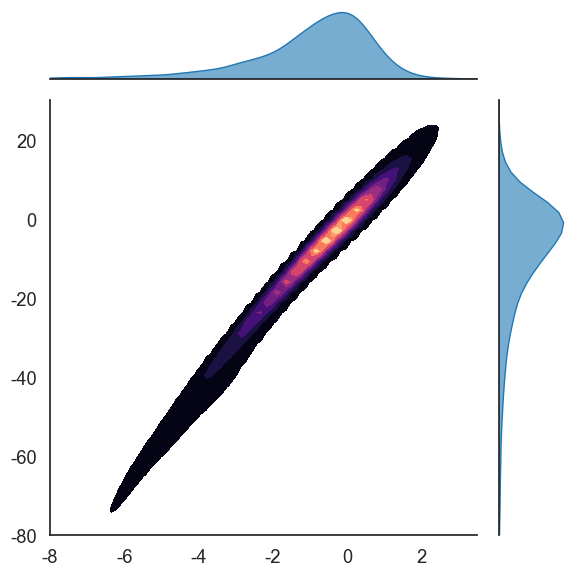

In [14]:
sns.set(style="white", font_scale=1.2)

sns.jointplot(
    x=File_S241011k_dquadS_doctS_Q,
    y=File_S241011k_dquadS_doctS_O,
    kind='kde',
    fill=True,
    cmap='magma',
    height=6,
    space=0,
    marginal_kws=dict(
        fill=True,
        color='#1f77b4',  
        alpha=0.6
    )
)
plt.xlim(-8,3.5)
plt.ylim(-80,30)

plt.tight_layout()
#plt.savefig('../fig/K2_L2_4parms_contour.png', dpi=300)
plt.show()

In [12]:
file=h5py.File(File_S241011k_dquad1_doct1)
file1=h5py.File(File_S241011k_dquadS_doctS)
plist=['mass_ratio','chi_eff','chi_p','chirp_mass','dQuadMon1','dOctupole1']
plist1=['mass_ratio','chi_eff','chi_p','chirp_mass','dQuadMonS','dOctupoleS']
extracted_sim=extract_dchi(file['posterior'],plist)
extracted_sim1=extract_dchi(file1['posterior'],plist1)
print(extracted_sim.shape)
print(extracted_sim1.shape)

(20000, 6)
(20000, 6)


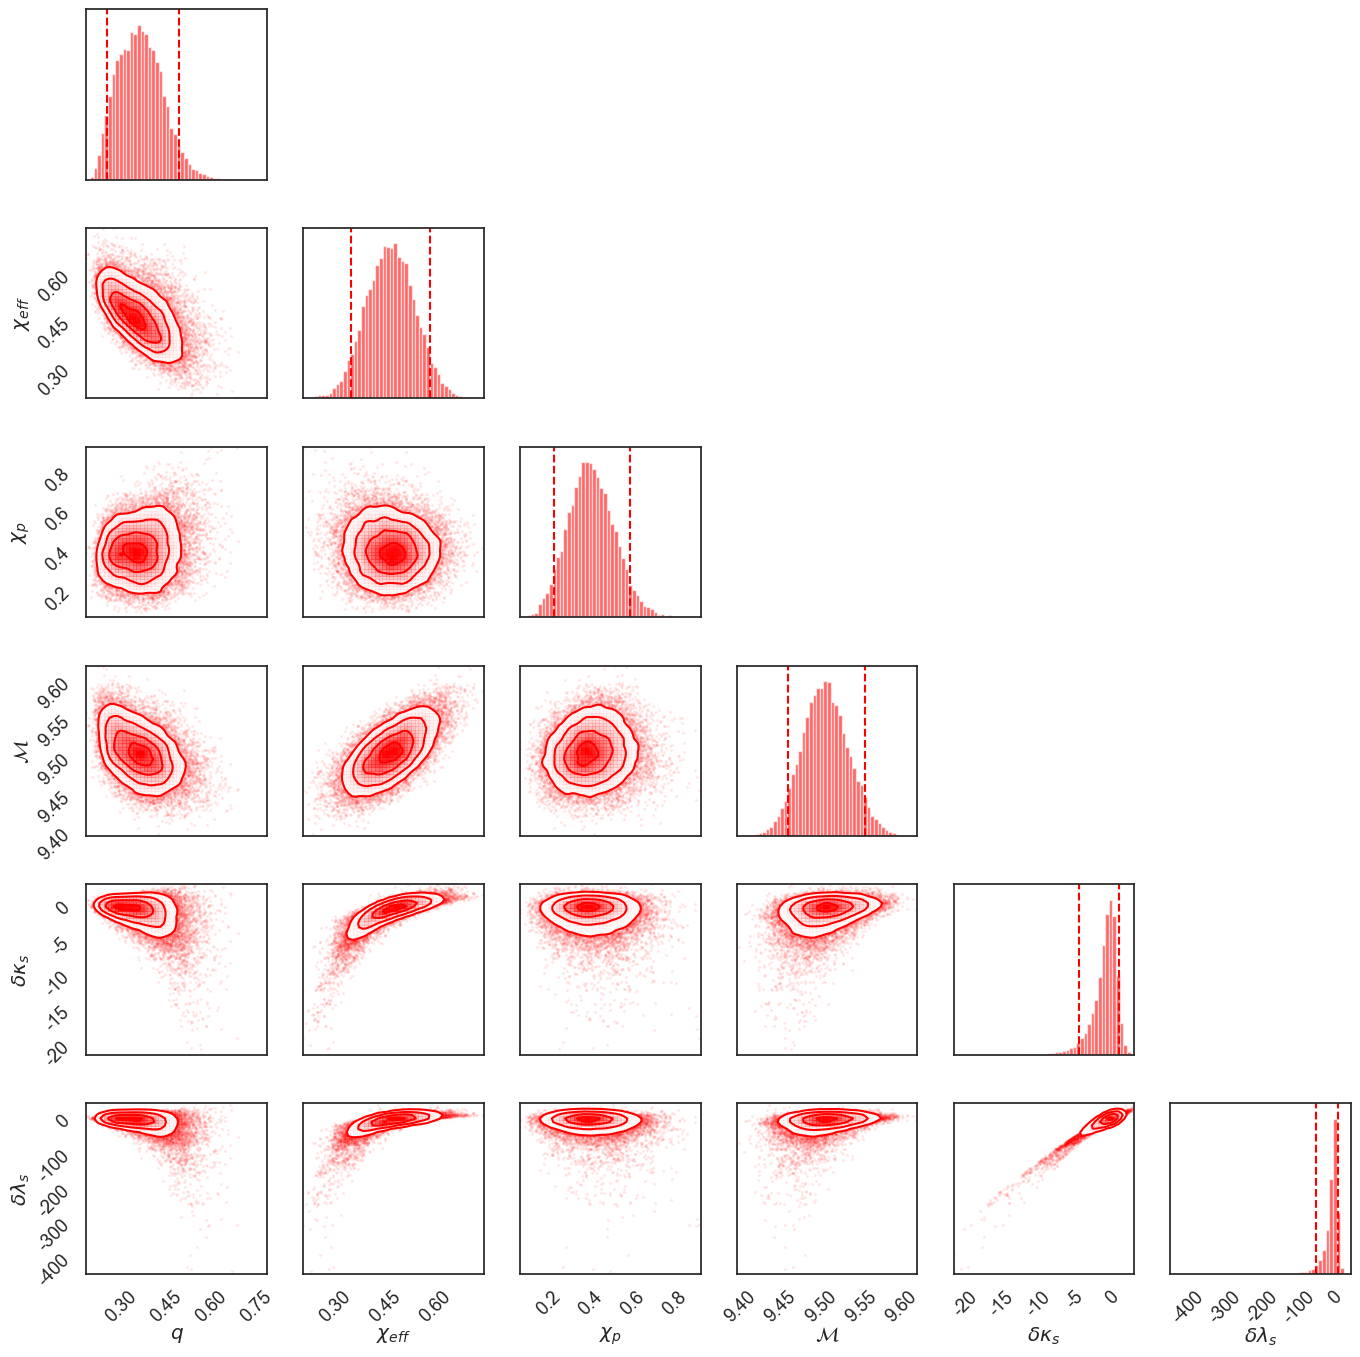

In [18]:
labels=['$q$','$\chi_{eff}$','$\chi_p$','$\cal{M}$','$\delta\kappa_1$', '$\delta\lambda_1$']
labels1=['$q$','$\chi_{eff}$','$\chi_p$','$\cal{M}$','$\delta\kappa_s$', '$\delta\lambda_s$']
'''
corner.corner(
    extracted_sim,
    labels=labels,
    color="grey",
    quantiles=[0.05, 0.95],
    bins=50,
    smooth=1.0,
    hist_kwargs={"density": True, "alpha": 0.6},
    #label_kwargs={"fontsize": 14}
)
plt.tight_layout()
'''
#plt.savefig('figures/corner_dk1_dl1.png')
corner.corner(
    extracted_sim1,
    labels=labels1,
    color="red",
    quantiles=[0.05, 0.95],
    bins=50,
    smooth=1.0,
    hist_kwargs={"density": True, "alpha": 0.6, "histtype":'bar'},
)

plt.tight_layout()
#plt.savefig('figures/corner_dks_dls.png')
plt.show()